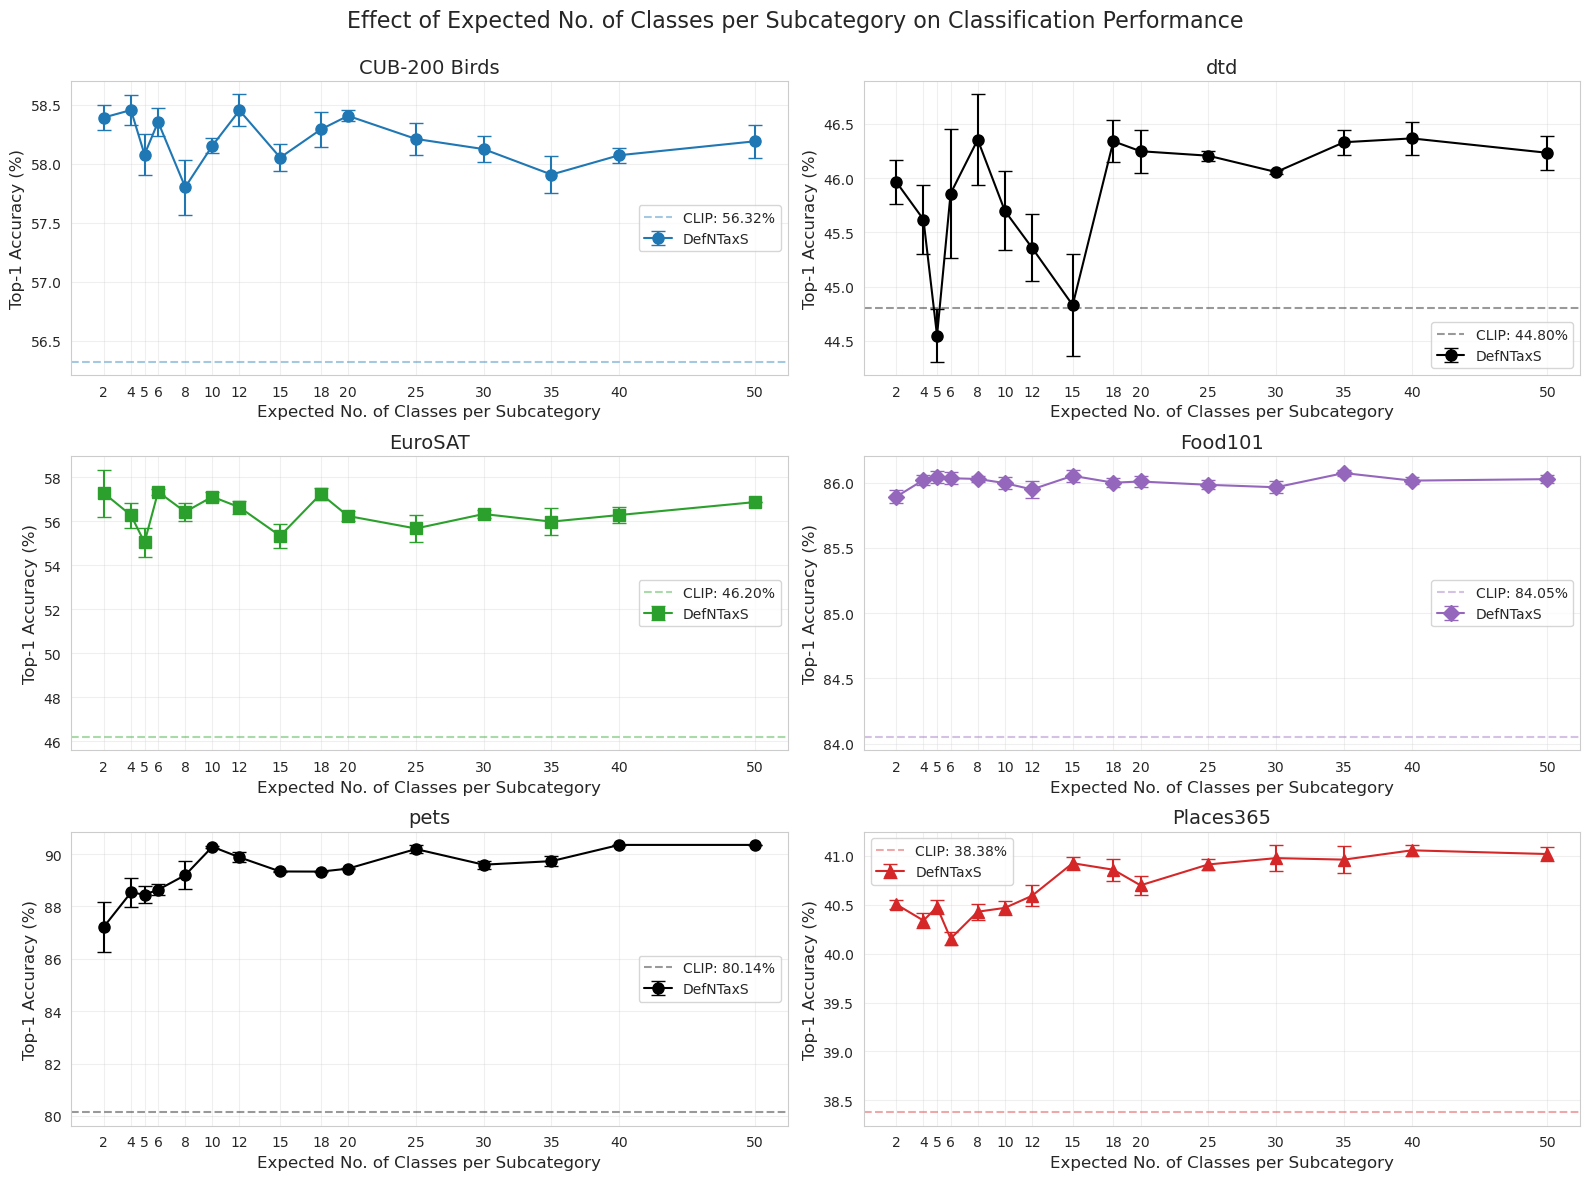

In [3]:
import json
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

import matplotlib.pyplot as plt

# Set a nice visualization style
sns.set_style("whitegrid")

# Load the data
with open('results/subcat_hparam_tests.json', 'r') as file:
    data = json.load(file)

# Extract the results into a dataframe
all_results = []
for model_name, model_data in data.items():
    for arch_name, arch_data in model_data.items():
        for method_name, method_data in arch_data.items():
            for dataset_name, dataset_results in method_data.items():
                for result in dataset_results:
                    all_results.append({
                        'dataset': dataset_name,
                        'seed': result['seed'],
                        'est_classes_per_subcategory': result['Est. classes per subcategory'],
                        'defntaxs_top1': result['Defntaxs Top-1 Accuracy'],
                        'clip_top1': result['CLIP Top-1 Accuracy']
                    })

df = pd.DataFrame(all_results)

# Group by dataset and est_classes_per_subcategory to calculate statistics
grouped = df.groupby(['dataset', 'est_classes_per_subcategory']).agg(
    defntaxs_top1_mean=('defntaxs_top1', 'mean'),
    defntaxs_top1_std=('defntaxs_top1', 'std'),
    defntaxs_top1_sem=('defntaxs_top1', lambda x: stats.sem(x)),
    clip_top1_mean=('clip_top1', 'mean')
).reset_index()

# Create a figure with 2x2 subplots (one for each dataset)
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()  # Flatten to make indexing easier

# Define colors and markers for different datasets
colors = {
    'cub': '#1f77b4',
    'eurosat': '#2ca02c',
    'places365': '#d62728',
    'food101': '#9467bd',
    'default': '#7f7f7f'  # Default color for any dataset not specified
}

markers = {
    'cub': 'o',
    'eurosat': 's',
    'places365': '^',
    'food101': 'D',
    'default': 'x'  # Default marker for any dataset not specified
}

# Nicer dataset names for the legend
dataset_display_names = {
    'cub': 'CUB-200 Birds',
    'eurosat': 'EuroSAT',
    'places365': 'Places365',
    'food101': 'Food101',
    'default': 'Other Datasets'  # Default name for any dataset not specified
}

# Get the list of datasets
datasets = sorted(grouped['dataset'].unique())

# Plot each dataset in its own subplot
for i, dataset in enumerate(datasets):
    ax = axes[i]  # Get the corresponding subplot
    dataset_data = grouped[grouped['dataset'] == dataset]
    dataset_data = dataset_data.sort_values('est_classes_per_subcategory')
    
    # Get CLIP baseline for this dataset
    clip_baseline = dataset_data['clip_top1_mean'].mean()
    
    # Plot DefNTaxS performance with error bars in this subplot
    ax.errorbar(
        dataset_data['est_classes_per_subcategory'], 
        dataset_data['defntaxs_top1_mean'],
        yerr=dataset_data['defntaxs_top1_sem'],
        fmt=f'-{markers[dataset]}' if dataset in markers else '-o',
        color=colors.get(dataset, 'black'),
        markersize=8,
        capsize=5,
        label='DefNTaxS'
    )
    
    # Add horizontal line for CLIP baseline
    ax.axhline(
        y=clip_baseline, 
        color=colors.get(dataset, 'black'), 
        linestyle='--', 
        alpha=0.4,
        label=f'CLIP: {clip_baseline:.2f}%'
    )
    
    # Set title and labels for this subplot
    ax.set_title(f'{dataset_display_names.get(dataset, dataset)}', fontsize=14)
    ax.set_xlabel('Expected No. of Classes per Subcategory', fontsize=12)
    ax.set_ylabel('Top-1 Accuracy (%)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    ax.set_xticks(sorted(dataset_data['est_classes_per_subcategory'].unique()))

# Add an overall title
plt.suptitle('Effect of Expected No. of Classes per Subcategory on Classification Performance', fontsize=16)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.92)  # Make room for the subtitle

plt.show()